# TP 2 — Clustering : solution commentée

Solution complète du [TP 2](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

X_blobs, y_blobs = make_blobs(n_samples=400, centers=4, cluster_std=0.7, random_state=0)
X_moons, y_moons = make_moons(n_samples=400, noise=0.08, random_state=0)
X_circles, y_circles = make_circles(n_samples=400, factor=0.5, noise=0.06, random_state=0)


def std(X):
    return StandardScaler().fit_transform(X)

## Exercice 1 — Coude + silhouette

k optimal (silhouette) = 4


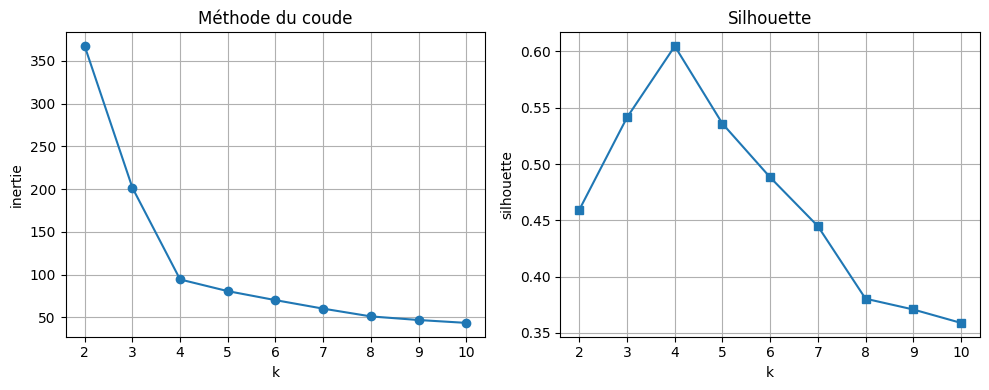

In [2]:
X = std(X_blobs)
ks = range(2, 11)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_ for k in ks]
sils = [
    silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)) for k in ks
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(ks), inertias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertie")
axes[0].set_title("Méthode du coude")
axes[1].plot(list(ks), sils, "s-")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
axes[1].set_title("Silhouette")
for ax in axes:
    ax.grid(True)
plt.tight_layout()

print("k optimal (silhouette) =", list(ks)[int(np.argmax(sils))])

## Exercice 2 — 3 algorithmes sur make_moons

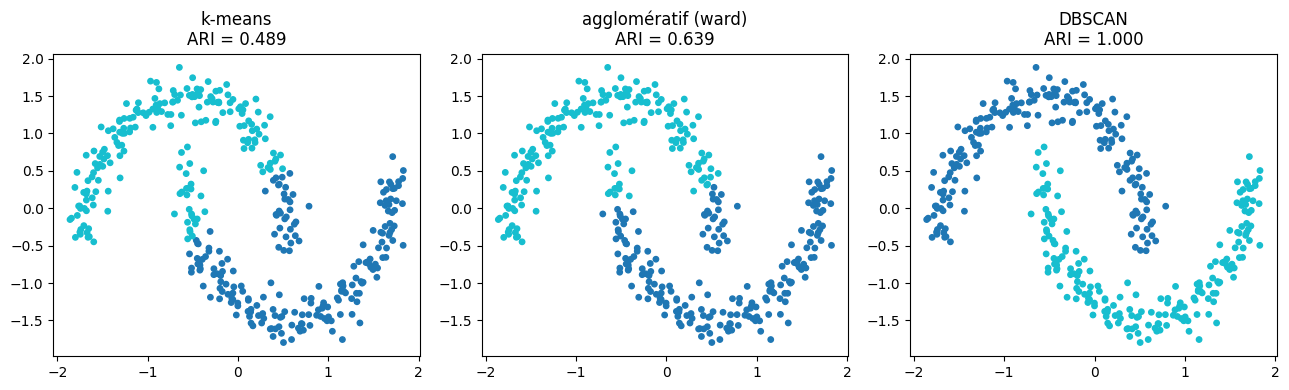

In [3]:
X = std(X_moons)
y = y_moons

labels_k = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X)
labels_a = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X)
labels_d = DBSCAN(eps=0.3, min_samples=5).fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, lab, name in zip(
    axes, [labels_k, labels_a, labels_d], ["k-means", "agglomératif (ward)", "DBSCAN"]
):
    ax.scatter(X[:, 0], X[:, 1], c=lab, cmap="tab10", s=15)
    ari = adjusted_rand_score(y, lab)
    ax.set_title(f"{name}\nARI = {ari:.3f}")
plt.tight_layout()

k-means et Ward échouent parce qu'ils recherchent des clusters globalement convexes / compacts. DBSCAN, qui suit la densité, attrape parfaitement les deux croissants.

## Exercice 3 — Cercles concentriques

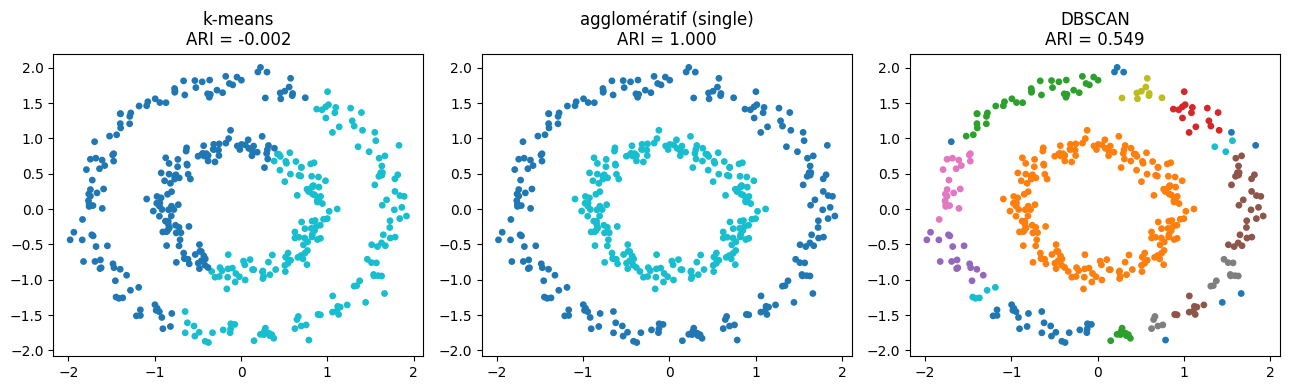

In [4]:
X = std(X_circles)
y = y_circles

labels_k = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X)
labels_a = AgglomerativeClustering(n_clusters=2, linkage="single").fit_predict(X)
labels_d = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, lab, name in zip(
    axes, [labels_k, labels_a, labels_d], ["k-means", "agglomératif (single)", "DBSCAN"]
):
    ax.scatter(X[:, 0], X[:, 1], c=lab, cmap="tab10", s=15)
    ax.set_title(f"{name}\nARI = {adjusted_rand_score(y, lab):.3f}")
plt.tight_layout()

In [5]:
# Bonus : sensibilité de DBSCAN à eps.
for eps in [0.1, 0.2, 0.4]:
    lab = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int((lab == -1).sum())
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} points bruit")

eps=0.1: 17 clusters, 246 points bruit
eps=0.2: 14 clusters, 9 points bruit
eps=0.4: 2 clusters, 0 points bruit


**Discussion** : k-means échoue ici aussi. L'agglomératif avec linkage **single** (qui privilégie la connectivité par chaînes) sépare le cercle interne du cercle externe — pratique mais sensible au bruit. DBSCAN reste l'outil le plus robuste sur ce type de structures, à condition de bien régler `eps`. Trop petit → tout devient bruit, trop grand → tout fusionne.